Trial 5 Complete [00h 00m 57s]
val_loss: 0.0007625498110428452

Best val_loss So Far: 0.0007393299019895494
Total elapsed time: 00h 05m 15s


/home/qa/runtime/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,465 (806.50 KB)

 Trainable params: 206,465 (806.50 KB)

 Non-trainable params: 0 (0.00 B)

None
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Next 5 Days Prediction Metrics:
MAE: 264.9481
RMSE: 300.5994
Directional Accuracy: 20.00%


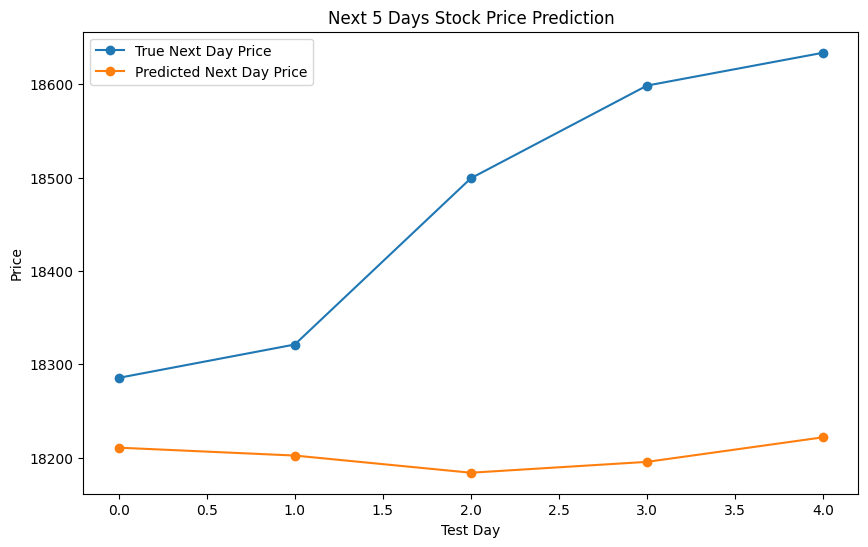

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# -----------------------------
# 1. Data Loading and Technical Indicators
# -----------------------------
# Adjust the file path to your NIFTY daily OHLC data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/nifty_1d_10y.csv',
                parse_dates=['Date'], index_col='Date')

del df["Dividends"]
del df["Stock Splits"]
df.index = pd.to_datetime(df.index, utc=True)
df.sort_index(inplace=True)

# Compute several technical indicators
def add_indicators(df):
    # Simple Moving Averages
    df['SMA_5']   = df['Close'].rolling(window=5).mean()
    df['SMA_10']  = df['Close'].rolling(window=10).mean()
    df['SMA_20']  = df['Close'].rolling(window=20).mean()
    # Exponential Moving Averages
    df['EMA_5']   = df['Close'].ewm(span=5, adjust=False).mean()
    df['EMA_10']  = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_20']  = df['Close'].ewm(span=20, adjust=False).mean()
    # Relative Strength Index (RSI) with period 14
    delta = df['Close'].diff()
    gain  = delta.where(delta > 0, 0)
    loss  = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    # Bollinger Bands (20-day SMA ± 2 stdev)
    df['BB_Mid']   = df['Close'].rolling(window=20).mean()
    df['BB_Std']   = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Mid'] + (df['BB_Std'] * 2)
    df['BB_Lower'] = df['BB_Mid'] - (df['BB_Std'] * 2)
    # MACD: 12-day EMA minus 26-day EMA and Signal line (9-day EMA of MACD)
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    # Fill NaN values (from rolling calculations)
    df = df.fillna(method='bfill')
    return df

df = add_indicators(df)

# Define feature columns (using OHLC, Volume, and indicators)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'SMA_5', 'SMA_10', 'SMA_20',
                'EMA_5', 'EMA_10', 'EMA_20',
                'RSI_14',
                'BB_Upper', 'BB_Lower', 'BB_Mid',
                'MACD', 'MACD_Signal']

df = df[feature_cols].copy()

# -----------------------------
# 2. Create Targets
# -----------------------------
# Target 1: Next day's closing price (for regression)
df['Target'] = df['Close'].shift(-1)
# Target 2: Direction of movement (1 if next day's close > today's close, else 0)
df['Direction'] = (df['Target'] > df['Close']).astype(int)
df.dropna(inplace=True)  # Remove the last row where target is NaN

# -----------------------------
# 3. Train-Test Split & Scaling
# -----------------------------
# Split into training and testing sets (e.g. 80% training, 20% testing)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

# Fit scaler on training data (all columns including targets) and transform both sets
scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_df)
test_scaled  = scaler.transform(test_df)

# Our data now has columns in the following order:
# feature_cols, 'Target', 'Direction'
all_columns = list(train_df.columns)
# Identify indices for features, target, and direction
feature_index = [all_columns.index(c) for c in feature_cols]
target_index  = all_columns.index('Target')
direction_index = all_columns.index('Direction')

# -----------------------------
# 4. Create Sequences for LSTM
# -----------------------------
def create_sequences(data, seq_length):
    X = []
    y = []
    d = []  # direction labels
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, feature_index])
        y.append(data[i, target_index])
        d.append(data[i, direction_index])
    return np.array(X), np.array(y), np.array(d)

seq_length = 60  # Use past 60 days to predict next day
X_train, y_train, d_train = create_sequences(train_scaled, seq_length)
X_test, y_test, d_test   = create_sequences(test_scaled, seq_length)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -----------------------------
# 5. Build and Tune the LSTM Model with Keras Tuner
# -----------------------------
def build_model(hp):
    model = Sequential()
    # First LSTM layer (with tunable number of units and dropout)
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                   return_sequences=True,
                   input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    # Second LSTM layer
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=32)))
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))
    # Output layer (predict next day's closing price)
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Use RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,  # Increase this number for a more thorough search
    executions_per_trial=1,
    directory='lstm_tuner',
    project_name='nifty_prediction'
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Run hyperparameter search
tuner.search(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]
print(best_model.summary())

# -----------------------------
# 6. Rolling Window Prediction for Next 5 Days
# -----------------------------
# We simulate a rolling window where for each test day we predict T+1 using available data.
# (Since our test set is already sequential, we’ll use the first 5 samples as our rolling predictions.)
predicted_prices_scaled = []
predicted_directions = []
true_prices_scaled = []
true_directions = []

for i in range(5):
    # Predict next day price using sample i of X_test
    pred = best_model.predict(np.expand_dims(X_test[i], axis=0))[0,0]
    predicted_prices_scaled.append(pred)
    true_prices_scaled.append(y_test[i])
    
    # Determine predicted direction: compare predicted price with last day’s close in input sequence
    last_close = X_test[i][-1, feature_cols.index('Close')]
    pred_dir = 1 if pred > last_close else 0
    predicted_directions.append(pred_dir)
    true_directions.append(d_test[i])

# To get the actual price values, we need to inverse transform.
# Since our scaler was fit on all columns, we prepare a dummy row with the predicted target in the correct column.
def inverse_transform_price(scaled_val):
    dummy = np.zeros((1, len(all_columns)))
    dummy[0, target_index] = scaled_val
    inv = scaler.inverse_transform(dummy)
    return inv[0, target_index]

predicted_prices = [inverse_transform_price(p) for p in predicted_prices_scaled]
true_prices      = [inverse_transform_price(p) for p in true_prices_scaled]

# -----------------------------
# 7. Evaluation Metrics
# -----------------------------
mae  = mean_absolute_error(true_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(true_prices, predicted_prices))
dir_acc = accuracy_score(true_directions, predicted_directions) * 100

print("\nNext 5 Days Prediction Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Directional Accuracy: {dir_acc:.2f}%")

# -----------------------------
# 8. Visualization
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(true_prices, label='True Next Day Price', marker='o')
plt.plot(predicted_prices, label='Predicted Next Day Price', marker='o')
plt.title("Next 5 Days Stock Price Prediction")
plt.xlabel("Test Day")
plt.ylabel("Price")
plt.legend()
plt.show()
